<a href="https://colab.research.google.com/github/RitvikM29/Deep_Learning_Codes/blob/main/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 0.2559 - val_loss: 0.1691
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1510 - val_loss: 0.1361
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1313 - val_loss: 0.1248
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1235 - val_loss: 0.1201
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.1186 - val_loss: 0.1151
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1147 - val_loss: 0.1113
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1113 - val_loss: 0.1082
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1083 - val_loss: 0.1059
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1058 - val_loss: 0.1039
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1039 - val_loss: 0.1019
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


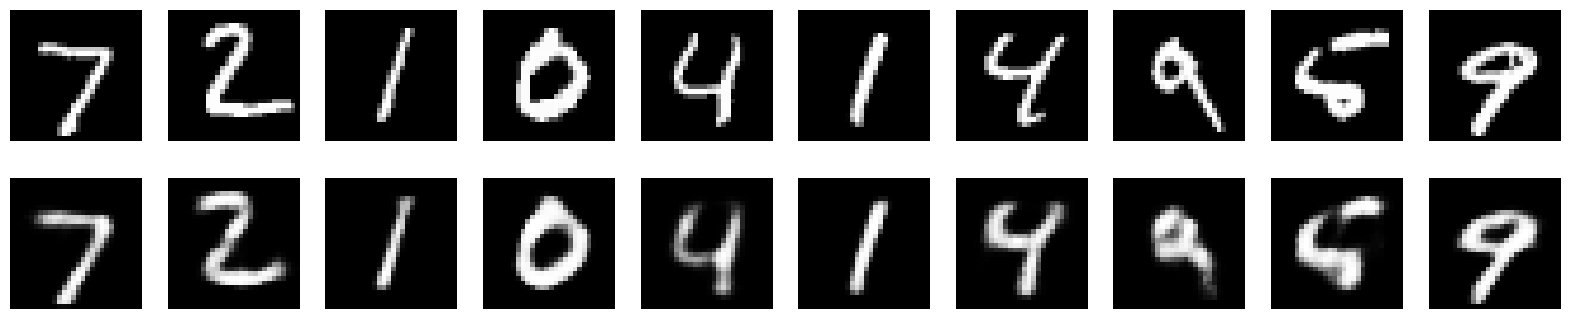

In [4]:
############
#
# Autoencoders
#
###########
### Import packages
import tensorflow as tf 	# build and train the neural network
from tensorflow.keras import layers  	# create neural network layers
from tensorflow.keras import models 	# define the complete model
import matplotlib.pyplot as plt 	# display images

### Load MNIST dataset
# Loads the MNIST dataset, which contains images of handwritten digits (0–9).
# x_train has training images.
# x_test has testing images.
# _ means we ignore the labels because autoencoders do not need them.

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

### Normalize pixel values
# Pixel values in images range from 0 to 255.
# Dividing by 255 converts them to 0–1 range.
# Helps the neural network learn better.

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

### Flatten images (28x28 → 784)
# Each image is 28 × 28 pixels.
# Neural networks often need 1D vectors, so convert:28 × 28 = 784 pixels
# Each image becomes a 784-length vector.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

### Encoder
# Input(shape=(784,)) - input layer for 784 pixel values.
# Dense layers gradually reduce the data size:
# 784 to 128
# 128 to 64
# 64 to 32
# The 32-unit layer is called the bottleneck layer, which stores the compressed representation of the image.

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)
encoded = layers.Dense(64, activation='relu')(encoded)
encoded = layers.Dense(32, activation='relu')(encoded)  # bottleneck layer

### Decoder
# The decoder reconstructs the image by expanding the compressed data:
# 32 to 64
# 64 to 128
# 128 to 784
# The final layer outputs 784 values, which represent the reconstructed image pixels.
# sigmoid ensures output values stay between 0 and 1.

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

### Autoencoder model
# connects the encoder and decoder into one complete model.
# Input → Encoder → Compressed Representation → Decoder → Reconstructed Image.

autoencoder = models.Model(input_img, decoded)

### Compile model
# optimizer = adam - adjusts weights to improve learning.
# loss = binary_crossentropy - measures how close reconstructed images are to original images.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train model

# The model learns by comparing input images with their own outputs.
# epochs=10 - training repeats 10 times.
# batch_size=256 - processes 256 images at a time.
# shuffle=True - randomizes training data.
# Validation checks performance using test data.


history = autoencoder.fit(
    x_train, x_train,
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct images
# The trained model tries to recreate the test images.

decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
# Original Images
# Reconstructed Images (from compressed data)
# If the model trained well, the reconstructed images will look very similar to the originals.

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()

Epoch 1/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.2673 - val_loss: 0.2099
Epoch 2/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1903 - val_loss: 0.1733
Epoch 3/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1663 - val_loss: 0.1592
Epoch 4/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1555 - val_loss: 0.1508
Epoch 5/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1486 - val_loss: 0.1450
Epoch 6/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1441 - val_loss: 0.1413
Epoch 7/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1408 - val_loss: 0.1390
Epoch 8/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1381 - val_loss: 0.1370
Epoch 9/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1357 - val_loss: 0.1340
Epoch 10/10
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1337 - val_loss: 0.1327
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


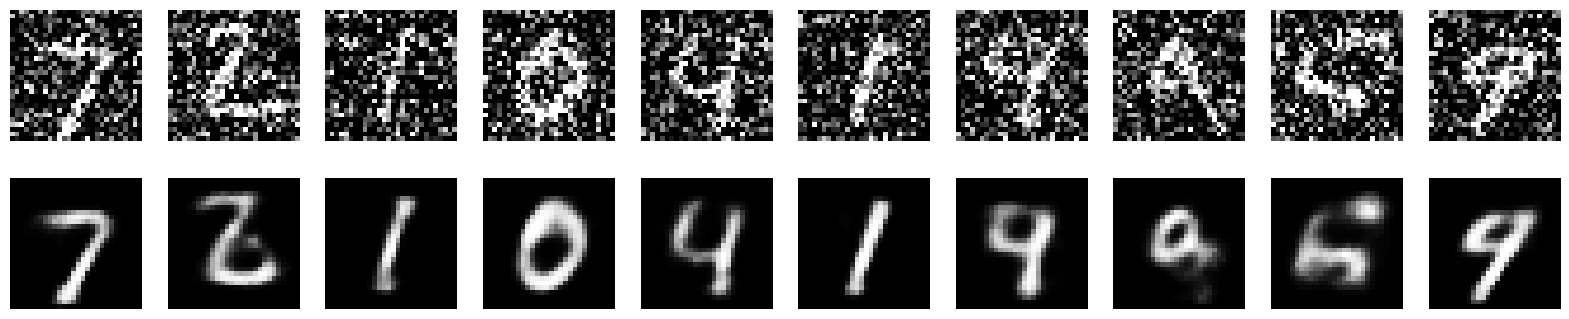

In [5]:
############
#
# Denoising Autoencoder
#
###########

### Import packages
import tensorflow as tf             # used to build and train the neural network
from tensorflow.keras import layers # helps create neural network layers
from tensorflow.keras import models # used to connect layers into a model
import matplotlib.pyplot as plt     # used to display images

### Load MNIST dataset
# The MNIST dataset contains images of handwritten digits (0–9).
# x_train contains training images.
# x_test contains testing images.
# We ignore the labels (_) because the autoencoder only needs images.

(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

### Normalize pixel values
# Image pixels normally range from 0 to 255.
# Dividing by 255 converts them to values between 0 and 1.
# This makes training easier and faster for the neural network.

x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.

### Add noise to images
# Here we intentionally add random noise to the images.
# The goal of a Denoising Autoencoder is to learn how to remove this noise.

import numpy as np

noise_factor = 0.5   # controls how much noise is added

x_train_noisy = x_train + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_train.shape)
x_test_noisy = x_test + noise_factor * np.random.normal(loc=0.0, scale=1.0, size=x_test.shape)

# Ensure pixel values stay within the valid range (0 to 1)

x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

### Flatten images (28x28 → 784)
# Each image has size 28 × 28 pixels.
# Neural networks usually work with 1-dimensional vectors.
# So we convert each image into a vector of 784 values.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

x_train_noisy = x_train_noisy.reshape((len(x_train_noisy), 784))
x_test_noisy = x_test_noisy.reshape((len(x_test_noisy), 784))

### Encoder
# The encoder compresses the noisy image into a smaller representation.
# Input layer receives 784 pixel values.
# Then the network gradually reduces the size of the data.

input_img = layers.Input(shape=(784,))
encoded = layers.Dense(128, activation='relu')(input_img)   # reduce size
encoded = layers.Dense(64, activation='relu')(encoded)      # further compression
encoded = layers.Dense(32, activation='relu')(encoded)      # bottleneck layer

# The bottleneck layer stores the most important information about the image.

### Decoder
# The decoder rebuilds the clean image from the compressed representation.
# The network gradually increases the size back to 784 pixels.

decoded = layers.Dense(64, activation='relu')(encoded)
decoded = layers.Dense(128, activation='relu')(decoded)
decoded = layers.Dense(784, activation='sigmoid')(decoded)

# The final layer outputs 784 values representing the reconstructed image.

### Denoising Autoencoder model
# This connects the encoder and decoder together.
# Flow: Noisy Image → Encoder → Bottleneck → Decoder → Clean Image

autoencoder = models.Model(input_img, decoded)

### Compile model
# The optimizer helps the model learn better weights.
# The loss function measures the difference between original clean images and reconstructed images.

autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

### Train model
# Important idea of denoising autoencoder:
# Input  = noisy images
# Output = clean images

history = autoencoder.fit(
    x_train_noisy, x_train,      # noisy input → clean target
    epochs=10,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

### Reconstruct images
# The trained model now tries to remove noise from the test images.

decoded_imgs = autoencoder.predict(x_test_noisy)

### Plot noisy vs cleaned images
# First row  → noisy images
# Second row → cleaned images predicted by the model

n = 10
plt.figure(figsize=(20, 4))

for i in range(n):

    # Noisy Image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test_noisy[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

    # Cleaned Image (Model Output)
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    plt.axis("off")

plt.show()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 9s 18ms/step - loss: 0.2970 - val_loss: 0.1966
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1833 - val_loss: 0.1732
Epoch 3/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1662 - val_loss: 0.1628
Epoch 4/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1601 - val_loss: 0.1567
Epoch 5/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.1569 - val_loss: 0.1546
Epoch 6/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1548 - val_loss: 0.1516
Epoch 7/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1523 - val_loss: 0.1496
Epoch 8/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1510 - val_loss: 0.1487
Epoch 9/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1500 - val_loss: 0.1480
Epoch 10/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1493 - val_loss: 0.1481
Epoch 11/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1491 - val_loss: 0.1470


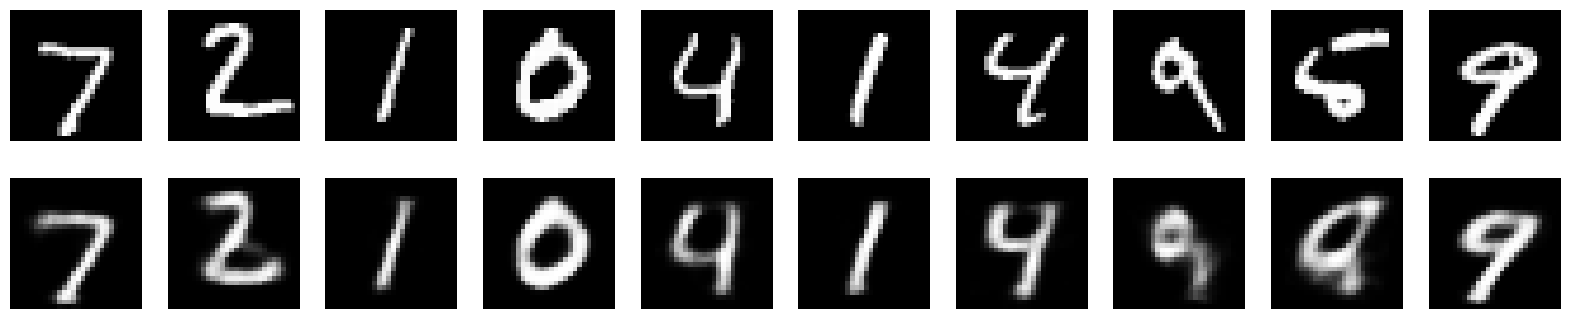

In [1]:
############
#
# Regularized Deep Autoencoder
# (with L2 weight decay)
#
############

### Import libraries
import tensorflow as tf
from tensorflow import keras
from keras import layers, regularizers
import matplotlib.pyplot as plt
import numpy as np

### Load MNIST dataset
(x_train, _), (x_test, _) = keras.datasets.mnist.load_data()

# Normalize pixel values to range 0–1
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

# Flatten images from 28x28 → 784 pixels
x_train = x_train.reshape((-1, 784))
x_test = x_test.reshape((-1, 784))

### Hyperparameters
input_dim = 784          # 28x28 images
encoding_dim1 = 512       # first hidden layer
encoding_dim2 = 256       # second hidden layer (bottleneck)
encoding_dim3 = 128       # third hidden layer (optional smaller bottleneck)
reg_factor = 1e-4        # L2 regularization factor

### Encoder
input_img = keras.Input(shape=(input_dim,))

# First hidden layer with L2 regularization
encoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(input_img)

# Second hidden layer
encoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

# Third hidden layer (bottleneck)
encoded = layers.Dense(
    encoding_dim3,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

### Decoder
# Mirror the encoder architecture
decoded = layers.Dense(
    encoding_dim2,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(encoded)

decoded = layers.Dense(
    encoding_dim1,
    activation="relu",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

# Output layer reconstructs original 784-pixel image
decoded = layers.Dense(
    input_dim,
    activation="sigmoid",
    kernel_regularizer=regularizers.l2(reg_factor)
)(decoded)

### Autoencoder model
autoencoder = keras.Model(inputs=input_img, outputs=decoded)

### Compile model
# optimizer=adam → standard choice for training deep networks
# loss=binary_crossentropy → works well for normalized pixel values
autoencoder.compile(optimizer="adam", loss="binary_crossentropy")

### Train model
history = autoencoder.fit(
    x_train, x_train,             # input = output for autoencoder
    epochs=20,
    batch_size=256,
    shuffle=True,
    validation_data=(x_test, x_test)
)

### Reconstruct test images
decoded_imgs = autoencoder.predict(x_test)

### Plot original vs reconstructed images
n = 10  # number of images to display
plt.figure(figsize=(20,4))
for i in range(n):
    # Original image
    ax = plt.subplot(2, n, i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap="gray")
    plt.axis("off")

    # Reconstructed image
    ax = plt.subplot(2, n, i+n+1)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap="gray")
    plt.axis("off")

plt.show()